## Import library and data

In [31]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import pickle
from backtesting import Backtest, Strategy

In [3]:
df = pd.read_csv('data/df_GOOG_alphabet.csv', parse_dates=['Date'], index_col=0)
df.head()

,Close,High,Low,Open,Volume,change_tmr,change_tmr_direction
Date,,,,,,,
2015-08-07,31.651274,32.018952,31.372775,31.896893,28078000,-0.247732,DOWN
2015-08-10,31.573057,32.056819,31.449451,31.859528,36184000,4.093648,UP
2015-08-11,32.920715,33.624185,32.596380,33.340206,100584000,-0.184966,DOWN
2015-08-12,32.859936,33.130961,32.497735,33.035304,58734000,-0.473778,DOWN
2015-08-13,32.704987,33.106046,32.466395,32.848073,36214000,0.101967,UP


* `parse_dates` to turn into datetime format
* `index_col=0` to set column 0 as index

In [9]:
# df.tail()
# Drop NaN
df.dropna(inplace=True)
df.isnull().sum()

Close                   0
High                    0
Low                     0
Open                    0
Volume                  0
change_tmr              0
change_tmr_direction    0
dtype: int64

In [10]:
target = df.change_tmr #numeric
explanatory = df[['Close', 'High', 'Low', 'Open', 'Volume']]

## Base model: Decision Tree Regressor

In [14]:
model_dt = DecisionTreeRegressor(max_depth=25)#to limit the training plotting time

In [15]:
model_dt.fit(X=explanatory, y=target)

DecisionTreeRegressor(max_depth=25)

Visualize the model:

In [ ]:
plot_tree(decision_tree=model_dt, feature_names=model_dt.feature_names_in_)

Calculate the prediction

In [17]:
y_pred = model_dt.predict(X=explanatory)

Compare how the prediction different from the actual data:

In [18]:
df_predictions = df[['change_tmr']].copy()

df_predictions['predictions'] = y_pred
df_predictions.head()

,change_tmr,predictions
Date,,
2015-08-07,-0.247732,0.009415
2015-08-10,4.093648,4.093648
2015-08-11,-0.184966,-0.184966
2015-08-12,-0.473778,-0.473778
2015-08-13,0.101967,0.101967


### Evaluate the model: 
`model_dt.score`

In [19]:
model_dt.score(X=explanatory, y=target)

0.7004138550063441

70% of the time, the model could predict the percent change accurately.

In [ ]:
df_predictions['error'] = df_predictions.predictions - df_predictions.change_tmr
df_predictions.error.sum().round(2) # not refelcting truth, need to convert to absolute or squared value 

np.float64(-0.0)

In [ ]:
df_predictions['erro2'] = df_predictions.error**2#.abs()
sse = df_predictions.erro2.sum(); sse #sum squared error

np.float64(2323.396223609754)

In [23]:
mse = df_predictions.erro2.mean(); mse #mean squared error

np.float64(0.9701028073527157)

In [26]:
rmse = np.sqrt(mse); rmse

np.float64(0.9849379713224157)

Histogram of the error to better interpret these number:

<Axes: >

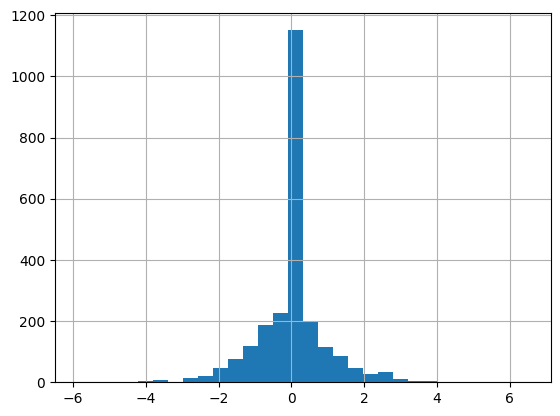

In [27]:
df_predictions.error.hist(bins=30)

In [28]:
rmse*2

np.float64(1.9698759426448313)

* The histogram follows normal distribution, with the majority falling around 0.
* `rmse` could be interpreted as standard deviation
* 95% of the time, the error would be between +-1.97

### Save models to file:

In [30]:
with open('models/model_dt_regression.pkl', 'wb') as f:
    pickle.dump(model_dt, f)
    

Load the model:

In [ ]:
with open ('models/model_dt_regression.pkl', 'rb') as f:
    model_dt = pickle.load(f)

## Backtest
### Create Strategy Class

In [ ]:
class Regression(Strategy):
    def init(self):
        self.model = model_dt
        self.already_bought = False
    
    def next(self):
        explanatory_dt = self.data.df.iloc[[-1],:]
        forecast_tmr = self.model.predict(explanatory_dt)[0]
        
        # conditions to buy or sell
        if forecast_tmr > 5 and self.already_bought == False:
            self.buy()
            self.already_bought = True
        elif forecast_tmr < -5 and self.already_bought== True:
            self.sell()
            self.already_bought = False
        else:
            pass

### Define initial conditions

In [ ]:
df_explanatory = df.drop(columns=['change_tmr', 'change_tmr_direction'])

In [38]:
bt = Backtest(df_explanatory, Regression, cash=10000, commission=0.002, exclusive_orders=True)

### Run backtesting

In [39]:
results = bt.run()

### Interpret backtesting results

In [40]:
results.to_frame(name='Values').loc[:'Return [%]']

,Values
Start,2015-08-07 00:00:00
End,2025-02-13 00:00:00
Duration,3478 days 00:00:00
Exposure Time [%],97.703549
Equity Final [$],56438.31876
Equity Peak [$],62387.31931
Commissions [$],2468.007637
Return [%],464.383188


In [ ]:
results.to_frame(name='Values').style

### Visualize the strategy performance

In [41]:
# Save the report
bt.plot(filename='reports_backtesting/dt_regression.html')

GridPlot(id='p1318', ...)

* Profit/Loss:
    * The highest profit we reached was about 40%
    * The worst loss was about 20%

## Optimize backtesting

In [42]:
# Load the ML model
with open('models/model_dt_regression.pkl', 'rb') as f:
    model_dt = pickle.load(f)

In [44]:
# Load the dt
df = pd.read_csv('data/df_GOOG_alphabet.csv', index_col=0, parse_dates=['Date'])
df.head()

,Close,High,Low,Open,Volume,change_tmr,change_tmr_direction
Date,,,,,,,
2015-08-07,31.651274,32.018952,31.372775,31.896893,28078000,-0.247732,DOWN
2015-08-10,31.573057,32.056819,31.449451,31.859528,36184000,4.093648,UP
2015-08-11,32.920715,33.624185,32.596380,33.340206,100584000,-0.184966,DOWN
2015-08-12,32.859936,33.130961,32.497735,33.035304,58734000,-0.473778,DOWN
2015-08-13,32.704987,33.106046,32.466395,32.848073,36214000,0.101967,UP


### 1. Set strategy parameter (attributes) directly under Regression

In [ ]:
class Regression(Strategy):
    limit_buy = 1
    limit_sell = -5
    
    def init(self):
        self.model = model_dt
        self.already_bought = False
    
    def next(self):
        explanatory_dt = self.data.df.iloc[[-1],:]
        forecast_tmr = self.model.predict(explanatory_dt)[0]
        
        # debug
        # print(f"Data:{self.data.index[-1]}, Prediction: {forecast_tmr}, Limit Buy: {self.limit_buy}, Limit Sell: {self.limit_sell}, Already Bought: {self.already_bought}")
        # conditions to buy or sell
        if forecast_tmr > self.limit_buy and self.already_bought == False:
            self.buy()
            self.already_bought = True
            # print(f"BUY at {self.data.index[-1]} at price {self.data.Close[-1]}") #debug
            
        elif forecast_tmr < self.limit_sell and self.already_bought== True:
            self.sell()
            self.already_bought = False
            # print(f"SELL at {self.data.index[-1]} at price {self.data.Close[-1]}") #debug

        else:
            pass

### 2. Create backtest class & parameters

In [100]:
df_explanatory = df.drop(columns=['change_tmr', 'change_tmr_direction'])

In [101]:
df_explanatory.iloc[-10:]

,Close,High,Low,Open,Volume
Date,,,,,
2025-02-03,202.639999,205.220001,201.660004,202.214996,16719500
2025-02-04,207.710007,208.699997,204.259995,204.500000,28285400
2025-02-05,193.300003,194.550003,189.910004,193.100006,43666400
2025-02-06,193.309998,193.830002,190.490005,190.990005,20816600
2025-02-07,187.139999,193.014999,185.100006,192.740005,29565700
2025-02-10,188.199997,189.990005,187.610001,189.059998,16606000
2025-02-11,187.070007,188.800003,186.080002,186.835007,13028100
2025-02-12,185.429993,186.830002,183.630005,185.229996,17632300
2025-02-13,187.880005,187.990005,184.880005,185.929993,12729300


In [102]:
model_dt.predict(df_explanatory.iloc[-10:])

array([ 1.86926258e-01, -7.45473535e+00,  5.17019656e-03, -3.29699593e+00,
        5.63229318e-01, -3.08432355e-01, -3.08432355e-01, -3.08432355e-01,
       -3.08432355e-01, -3.08432355e-01])

In [103]:
bt = Backtest(df_explanatory, Regression, cash=10000, commission=0.002, exclusive_orders=True)

`limit_buy` (0 to 10, y-axis): defines the threshold above which a buy order is placed.
* A higher `limit_buy` means the strategy is stricter (only buying when the model predicts a much stronger price increase)
* A lower `limit_buy`means more frequeny buys (weaker signals still qualify)

`limit_sell` (0 to -10, x-axis): defines the threshold below which a sell order is placed.
* A more negative `limit_sell` means stricter conditions for selling
* A `limit_sell` near 0 means sells sooner when a decline is predicted

In [96]:
list_limits_buy = list(range(0, 11, 1))
list_limits_buy

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [97]:
list_limits_sell = list(range(0, -11, -1))
list_limits_sell

[0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10]

### 3. Pass to function

In [ ]:
# %% time #only for jupter notebook
import time
start_time = time.time()

results = bt.optimize(
    limit_buy = list_limits_buy, limit_sell = list_limits_sell,
    maximize='Return [%]', return_heatmap=True
)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.4f} seconds")

Alternatives to time a function: `timeit`:

    ```{Python}
    execution_time = timeit.timeit(short function)
    print({execution_time:.4f} seconds)
    ```

### 4. Turn results into DataFrame

In [105]:
type(results)

tuple

In [ ]:
# results

In [106]:
dff = results[1].reset_index()

In [ ]:
# dff

In [107]:
dff.describe()

,limit_buy,limit_sell,Return [%]
count,121.000000,121.000000,110.000000
mean,5.000000,-5.000000,11468.019148
std,3.175426,3.175426,60409.108976
min,0.000000,-10.000000,-100.000000
25%,2.000000,-8.000000,-89.370963
50%,5.000000,-5.000000,131.367753
75%,8.000000,-2.000000,549.015116
max,10.000000,0.000000,552254.023690


In [110]:
dff_pivot = dff.pivot(index='limit_buy', columns='limit_sell', values='Return [%]')

In [75]:
#debugging background_graident AttributeError
print(pd.__version__)
print(dir(dff.style))

2.2.3
['__class__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_apply_index', '_check_trim', '_compute', '_copy', '_display_funcs', '_display_funcs_columns', '_display_funcs_index', '_generate_body_row', '_generate_col_header_row', '_generate_index_names_row', '_generate_trimmed_row', '_get_numeric_subset_default', '_map', '_render', '_render_html', '_render_latex', '_render_string', '_repr_html_', '_repr_latex_', '_todo', '_translate', '_translate_body', '_translate_header', '_translate_latex', '_update_ctx', '_update_ctx_header', 'apply', 'apply_index', 'applymap', 'applymap_index', 'background_gradient', 'bar', 'caption', 'cell_context', 'cell_ids', 'clear', 'co

* Check if `background_gradient` is there

### 5. Heatmap Return[%]

In [113]:
# sort column (axis=1)
dff_pivot.sort_index(axis=1, ascending=False)\
    .style.format(precision=0)\
        .background_gradient()#cmap='coolwarm'#, vmin=dff.values.min(), vmax=dff.values.max())


limit_sell,0,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10
limit_buy,,,,,,,,,,,
0,275864,552254,127334,26080,9455,3579,557,603,583,486,549
1,48438,87464,58243,23093,9949,4676,645,697,587,486,549
2,1219,1560,2854,3952,7728,3324,493,533,535,393,446
3,103,306,379,701,2126,1349,391,425,395,298,341
4,-84,-75,-56,-25,39,419,302,330,305,290,332
5,-90,-89,-90,-83,-66,34,45,56,46,176,206
6,-96,-95,-96,-94,-89,-50,13,-5,-10,176,206
7,-100,-100,-100,-100,-100,-77,6,-10,-16,160,187
8,-100,-100,-100,-100,-100,-100,-44,-82,-83,-83,-81


* Higher values mean the strategy performed well.
* Lower values mean the strategy lost money or didn't execute trades.
* After decision tree model (`model_dt`) predicts the probability of price changes, different `limit_buy` and `limit_sell` affect how often trades are made.
* Lower right are stricter limits; upper left are more aggressive limits (ie. buy and sell frequently).

In [114]:
model_dt.predict(df_explanatory).max()

np.float64(9.460104489110288)

* `style` converts it to a Styler object
* `format(precision=0)`: style without decimal

To color based on overall data result:
* `vmin=dff.values.min()`: defines the lowest value for the color gradient
* `vmax=dff.values.max()`: defines the highest value for the color gradient

Possible causes for NaN in row `limit_buy=10`:
1. `forecast_tmr` never exceeded `limit_buy=10`

### 6. Optimize backtesting with multiple combinations to reduce computing time

In [117]:
import multiprocessing as mp
if mp.get_start_method(allow_none=True) is None:
    mp.set_start_method('fork')

In [122]:
# debugging ImportError: Need package 'sambo' for method='sambo'. pip install sambo
# import backtesting
# backtesting.__version__
!pip install sambo

In [ ]:
stats_skopt, heatmap, optimize_result = bt.optimize(
    limit_buy = [0, 9],
    limit_sell = [-10, 0],
    maximize= 'Return [%]',
    method='skopt',
    max_tries=500,
    random_state=0,
    return_heatmap=True,
    return_optimization=True
)

* `method=`
    * `grid` (by default): an exhaustive (or randomized) search over the cartesian product of parameter combination
    * `skopt`: find close-to-optimal strategy parameters

#### Which are the best values for the parameters 

In [ ]:
# heatmap

In [125]:
type(heatmap)

pandas.core.series.Series

In [127]:
dff_tuned = heatmap.reset_index()
dff_tuned_pivot = dff_tuned.pivot(index='limit_buy', columns='limit_sell', values='Return [%]')
dff_tuned_pivot

limit_sell,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0
limit_buy,,,,,,,,,,,
0,NaN,NaN,NaN,603.278009,NaN,3578.511308,NaN,NaN,NaN,NaN,275863.871605
1,549.015116,NaN,586.560976,697.156705,645.137112,NaN,9948.895220,NaN,NaN,NaN,48437.869140
2,446.095102,392.752778,NaN,NaN,492.723825,3324.422008,NaN,NaN,2853.556999,NaN,NaN
3,340.614854,NaN,394.504997,NaN,NaN,1348.774006,NaN,701.013825,NaN,306.411808,103.138875
4,332.241625,290.140685,NaN,NaN,NaN,419.402421,38.737459,NaN,-55.859842,-74.874639,-83.838031
5,206.240611,176.141110,46.448963,NaN,NaN,NaN,NaN,-83.196818,NaN,-88.939955,NaN
6,206.240611,NaN,-10.172963,-4.621343,13.295060,NaN,-88.552569,-94.292047,NaN,-95.465210,-96.068009
7,NaN,NaN,-15.670366,NaN,6.066790,NaN,-100.000000,NaN,NaN,-100.000000,NaN
8,NaN,-82.979850,-82.979850,-81.927964,-43.616679,NaN,-100.000000,-100.000000,NaN,-100.000000,NaN


Apply color:

In [ ]:
dff_tuned_pivot.style.highlight_null(props='background-color: transparent; color: transparent') #to hide the NaN

limit_sell,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0
limit_buy,,,,,,,,,,,
0,nan,nan,nan,603.278009,nan,3578.511308,nan,nan,nan,nan,275863.871605
1,549.015116,nan,586.560976,697.156705,645.137112,nan,9948.895220,nan,nan,nan,48437.869140
2,446.095102,392.752778,nan,nan,492.723825,3324.422008,nan,nan,2853.556999,nan,nan
3,340.614854,nan,394.504997,nan,nan,1348.774006,nan,701.013825,nan,306.411808,103.138875
4,332.241625,290.140685,nan,nan,nan,419.402421,38.737459,nan,-55.859842,-74.874639,-83.838031
5,206.240611,176.141110,46.448963,nan,nan,nan,nan,-83.196818,nan,-88.939955,nan
6,206.240611,nan,-10.172963,-4.621343,13.295060,nan,-88.552569,-94.292047,nan,-95.465210,-96.068009
7,nan,nan,-15.670366,nan,6.066790,nan,-100.000000,nan,nan,-100.000000,nan
8,nan,-82.979850,-82.979850,-81.927964,-43.616679,nan,-100.000000,-100.000000,nan,-100.000000,nan


In [129]:
dff_tuned_pivot.sort_index(axis=1, ascending=False)\
    .style.format(precision=0)\
        .background_gradient(vmin=np.nanmin(dff_tuned_pivot), vmax=np.nanmax(dff_tuned_pivot))\
            .highlight_null(props='background-color: transparent; color: transparent')

limit_sell,0,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10
limit_buy,,,,,,,,,,,
0,275864,nan,nan,nan,nan,3579,nan,603,nan,nan,nan
1,48438,nan,nan,nan,9949,nan,645,697,587,nan,549
2,nan,nan,2854,nan,nan,3324,493,nan,nan,393,446
3,103,306,nan,701,nan,1349,nan,nan,395,nan,341
4,-84,-75,-56,nan,39,419,nan,nan,nan,290,332
5,nan,-89,nan,-83,nan,nan,nan,nan,46,176,206
6,-96,-95,nan,-94,-89,nan,13,-5,-10,nan,206
7,nan,-100,nan,nan,-100,nan,6,nan,-16,nan,nan
8,nan,-100,nan,-100,-100,nan,-44,-82,-83,-83,nan


## Conclusion:
The optimal number is at [0,0] in which the algorithm found. Which means the highest return occurs when no strict buy/sell thresholds are applied (ie. doing nothing (not trading, "hold") might be better than trading under the current conditions)
* This suggest the current decision tree model might not be providing effective predictions.
* Or the transaction cost might be too high, making frequent tradding unprofitable.


Furture steps:
1. Analyze why (0,0) is optimal?
2. Optimize and refine the strategy by adding more features or use other models like Random Forest, Gradient Boosting (as Decision Tree might be overfitting)


In [130]:
dff_tuned_pivot.loc[0,0]

np.float64(275863.8716053466)

In [131]:
dff_tuned_pivot.max().max()

np.float64(275863.8716053466)

[To further interpret smart optimization in plot](https://kernc.github.io/backtesting.py/doc/examples/Parameter%20Heatmap%20&%20Optimization.html#google_vignette)